# Steam Games – Data Mining Project
## Section 3: Exploratory Data Analysis

**Team 9 – Brewed Clusters**  
Owner: Arpitha Shivaprasad Kori

---

### What does this notebook do?

This notebook performs exploratory data analysis on the preprocessed multiclass dataset.  
It does **not** modify the data — the goal is to understand patterns and inform modelling decisions.

Analyses covered:
1. Class balance — Good / Mixed / Bad distribution
2. Price distribution across classes
3. Top genres and their relationship to reception
4. Top tags and their relationship to reception
5. Platform availability (Windows / Mac / Linux)
6. Release era distribution
7. Numeric feature distributions per class
8. Correlation heatmap of continuous features
9. Outlier identification (IQR method)
10. Language support vs reception

---
## Step 0 – Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='muted')

GOOD_COLOR  = 'steelblue'
MIXED_COLOR = 'sandybrown'
BAD_COLOR   = 'salmon'
CLASS_COLORS = {'Good': GOOD_COLOR, 'Mixed': MIXED_COLOR, 'Bad': BAD_COLOR}
CLASS_ORDER  = ['Good', 'Mixed', 'Bad']

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## Step 1 – Load Data

In [2]:
train = pd.read_csv('../Datasets/train_multiclass.csv')

X = train.drop(columns=['label_multiclass'])
y = train['label_multiclass']

continuous_cols = ['log_price', 'Required age', 'DiscountDLC count', 'Achievements', 'n_languages']

print(f'Train set      : {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Continuous cols: {continuous_cols}')
print()
print('Class distribution:')
print(y.value_counts())

Train set      : 45,324 rows × 147 features
Continuous cols: ['log_price', 'Required age', 'DiscountDLC count', 'Achievements', 'n_languages']

Class distribution:
label_multiclass
Good     28671
Mixed    12834
Bad       3819
Name: count, dtype: int64


---
## Step 2 – Class Balance

Three classes: **Good** (high positive reviews), **Mixed**, **Bad** (low positive reviews).

Class distribution:
  Good  :  28,671  (63.3%)
  Mixed :  12,834  (28.3%)
  Bad   :   3,819  (8.4%)


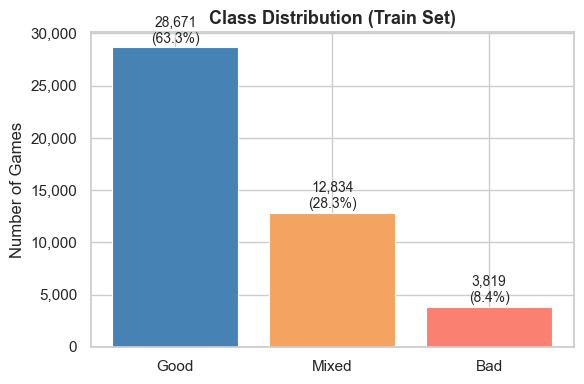

In [3]:
counts = y.value_counts()[CLASS_ORDER]
pcts   = y.value_counts(normalize=True)[CLASS_ORDER] * 100

print('Class distribution:')
for cls in CLASS_ORDER:
    print(f'  {cls:6s}: {counts[cls]:>7,}  ({pcts[cls]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(CLASS_ORDER, counts.values,
              color=[CLASS_COLORS[c] for c in CLASS_ORDER],
              edgecolor='white', linewidth=0.8)
for bar, val, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Class Distribution (Train Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Games')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## Step 3 – Price Distribution

Do free-to-play or cheap games tend to be Good, Mixed, or Bad?

Free-to-play: 0 (0.0%)
Paid        : 45,324 (100.0%)


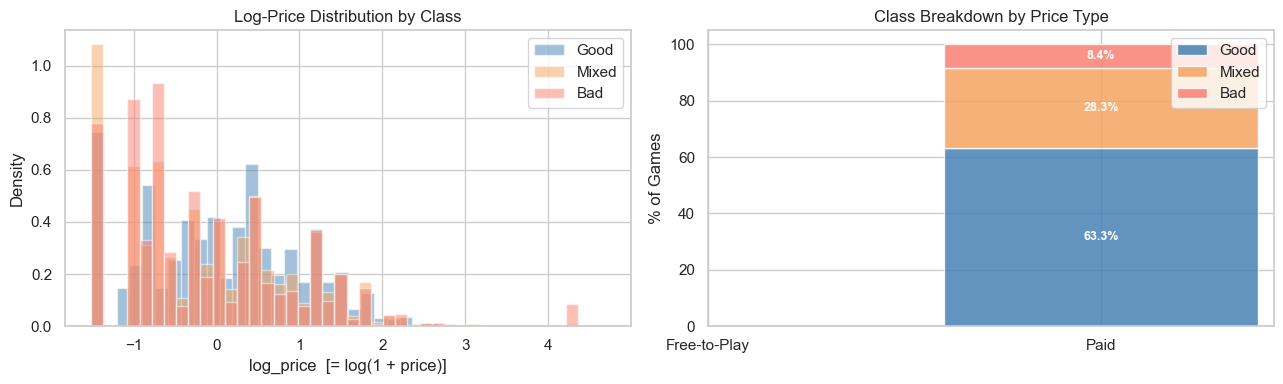

In [4]:
price_approx = np.expm1(X['log_price'])
is_free = (price_approx == 0)

print(f'Free-to-play: {is_free.sum():,} ({is_free.mean()*100:.1f}%)')
print(f'Paid        : {(~is_free).sum():,} ({(~is_free).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: log_price distribution by class
for cls in CLASS_ORDER:
    axes[0].hist(X.loc[y == cls, 'log_price'], bins=40, alpha=0.5,
                 color=CLASS_COLORS[cls], label=cls, density=True)
axes[0].set_title('Log-Price Distribution by Class')
axes[0].set_xlabel('log_price  [= log(1 + price)]')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: class breakdown for free vs paid (stacked %)
fig_data = {}
for grp, mask in [('Free', is_free), ('Paid', ~is_free)]:
    subset = y[mask]
    fig_data[grp] = {cls: (subset == cls).sum() / len(subset) * 100 for cls in CLASS_ORDER}

x_pos = np.arange(2)
bottoms = np.zeros(2)
for cls in CLASS_ORDER:
    vals = [fig_data['Free'][cls], fig_data['Paid'][cls]]
    axes[1].bar(x_pos, vals, bottom=bottoms, label=cls, color=CLASS_COLORS[cls], alpha=0.85)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 4:
            axes[1].text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                         fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(vals)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Free-to-Play', 'Paid'])
axes[1].set_ylabel('% of Games')
axes[1].set_title('Class Breakdown by Price Type')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## Step 4 – Top Genres

Genres are stored as binary dummy columns named `genre_*`.  
We look at the 15 most common genres and how their Good-rate compares to the overall baseline.

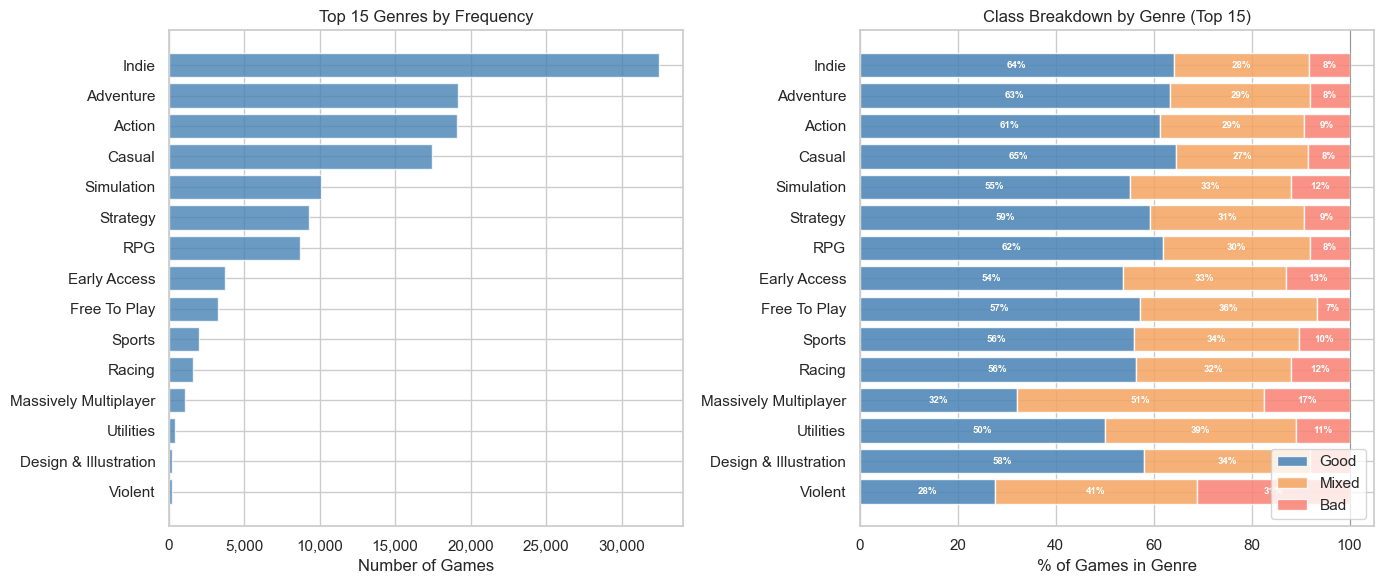

In [5]:
genre_cols = [c for c in X.columns if c.startswith('genre_')]

genre_counts = X[genre_cols].sum().sort_values(ascending=False).head(15)
top_genres   = genre_counts.index.tolist()
genre_labels = [c.replace('genre_', '') for c in top_genres]

# Class breakdown per genre (stacked %)
genre_breakdown = pd.DataFrame(index=top_genres, columns=CLASS_ORDER, dtype=float)
for col in top_genres:
    mask = X[col] == 1
    total = mask.sum()
    for cls in CLASS_ORDER:
        genre_breakdown.loc[col, cls] = (y[mask] == cls).sum() / total * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: frequency
axes[0].barh(genre_labels[::-1], genre_counts.values[::-1], color=GOOD_COLOR, alpha=0.8)
axes[0].set_xlabel('Number of Games')
axes[0].set_title('Top 15 Genres by Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: stacked % breakdown per genre
bottoms = np.zeros(15)
for cls in CLASS_ORDER:
    vals = genre_breakdown[cls].values[::-1]
    axes[1].barh(genre_labels[::-1], vals, left=bottoms,
                 label=cls, color=CLASS_COLORS[cls], alpha=0.85)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 6:
            axes[1].text(b + v/2, i, f'{v:.0f}%', ha='center', va='center',
                         fontsize=7, color='white', fontweight='bold')
    bottoms += vals
axes[1].set_xlabel('% of Games in Genre')
axes[1].set_title('Class Breakdown by Genre (Top 15)')
axes[1].legend(loc='lower right')
axes[1].axvline(100, color='grey', linewidth=0.5)

plt.tight_layout()
plt.show()

---
## Step 5 – Top Tags

Tags are user-defined labels stored as binary columns named `tag_*`.  
We kept the top 50 by frequency in preprocessing — here we visualise which tags are most associated with Good reception.

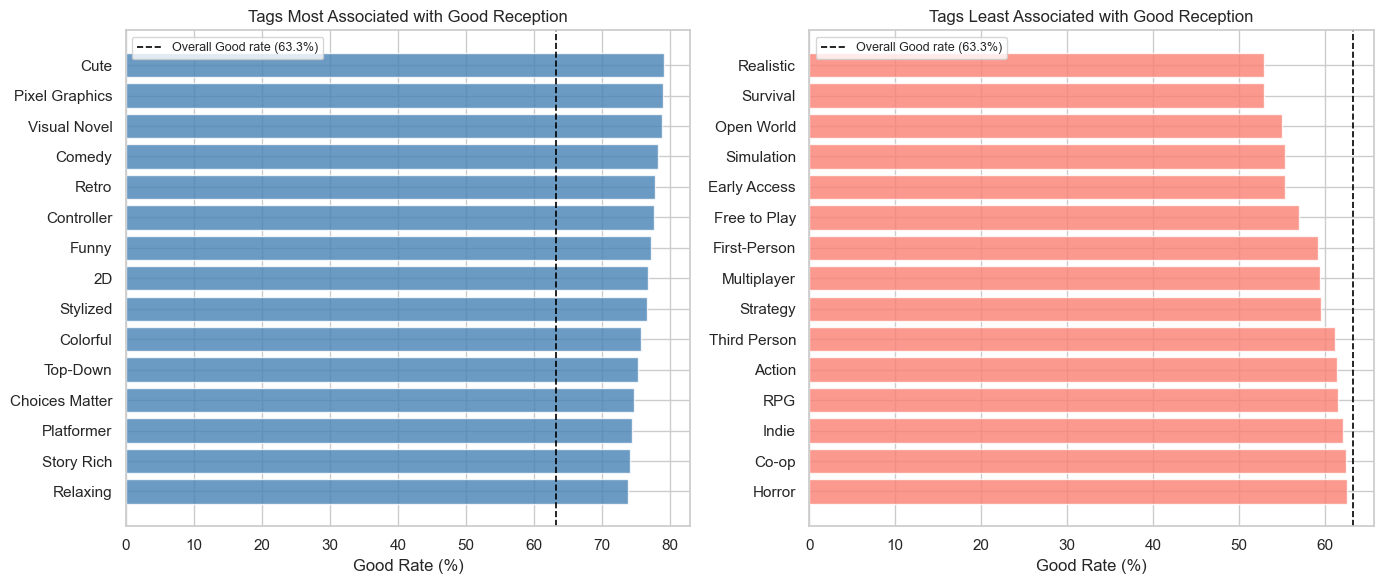

In [6]:
tag_cols = [c for c in X.columns if c.startswith('tag_')]

tag_good_rate = pd.Series({
    col: (y[X[col] == 1] == 'Good').mean()
    for col in tag_cols
}).sort_values(ascending=False)
tag_good_rate.index = [c.replace('tag_', '') for c in tag_good_rate.index]

top_tags    = tag_good_rate.head(15)
bottom_tags = tag_good_rate.tail(15)

overall_good_rate = (y == 'Good').mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_tags.index[::-1], top_tags.values[::-1] * 100,
             color=GOOD_COLOR, alpha=0.8)
axes[0].axvline(overall_good_rate, color='black', linestyle='--', linewidth=1.2,
                label=f'Overall Good rate ({overall_good_rate:.1f}%)')
axes[0].set_xlabel('Good Rate (%)')
axes[0].set_title('Tags Most Associated with Good Reception')
axes[0].legend(fontsize=9)

axes[1].barh(bottom_tags.index, bottom_tags.values * 100,
             color=BAD_COLOR, alpha=0.8)
axes[1].axvline(overall_good_rate, color='black', linestyle='--', linewidth=1.2,
                label=f'Overall Good rate ({overall_good_rate:.1f}%)')
axes[1].set_xlabel('Good Rate (%)')
axes[1].set_title('Tags Least Associated with Good Reception')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Step 6 – Platform Availability

Steam games can be released on Windows, Mac, and/or Linux.  
We check whether multi-platform availability correlates with reception quality.

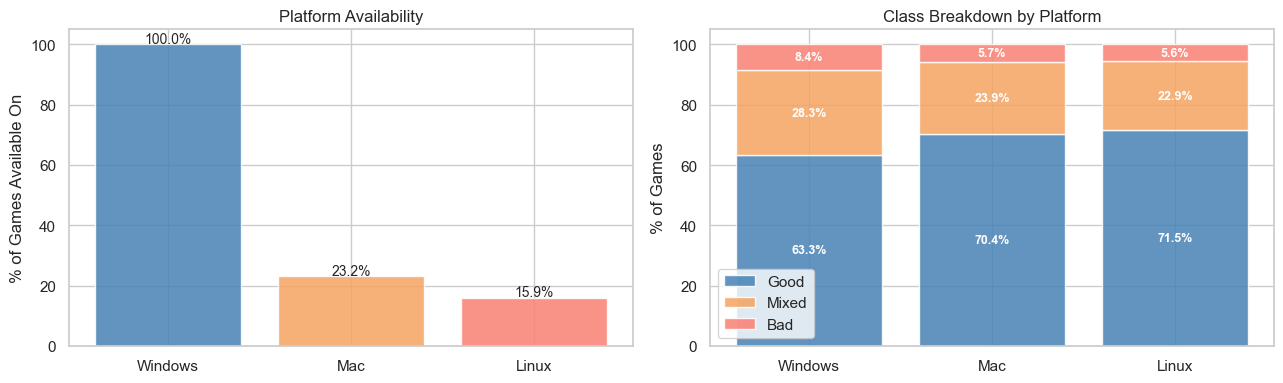

In [7]:
platform_cols = ['Windows', 'Mac', 'Linux']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: platform availability
pct_avail = (X[platform_cols].sum() / len(X) * 100)
axes[0].bar(platform_cols, pct_avail.values, color=[GOOD_COLOR, MIXED_COLOR, BAD_COLOR], alpha=0.85)
axes[0].set_ylabel('% of Games Available On')
axes[0].set_title('Platform Availability')
for i, v in enumerate(pct_avail.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

# Right: stacked class % per platform (stacked bar)
x_pos = np.arange(len(platform_cols))
bottoms = np.zeros(len(platform_cols))
for cls in CLASS_ORDER:
    vals = [((X[p] == 1) & (y == cls)).sum() / (X[p] == 1).sum() * 100
            for p in platform_cols]
    axes[1].bar(x_pos, vals, bottom=bottoms, label=cls, color=CLASS_COLORS[cls], alpha=0.85)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 4:
            axes[1].text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                         fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(vals)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(platform_cols)
axes[1].set_ylabel('% of Games')
axes[1].set_title('Class Breakdown by Platform')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 7 – Release Era Distribution

We grouped release years into three era buckets in preprocessing: pre-2015, 2015-2019, and 2020+.  
Here we check whether era affects reception and how many games fall in each bucket.

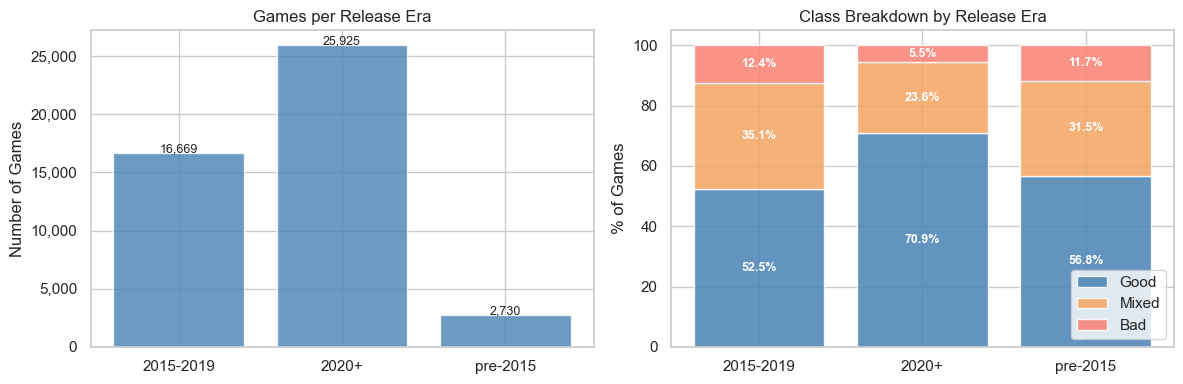

In [8]:
era_cols   = [c for c in X.columns if c.startswith('era_')]
era_labels = [c.replace('era_', '') for c in era_cols]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: game count per era
era_counts = X[era_cols].sum().values
axes[0].bar(era_labels, era_counts, color=GOOD_COLOR, alpha=0.8)
axes[0].set_ylabel('Number of Games')
axes[0].set_title('Games per Release Era')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(era_counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Right: stacked class % per era
x_pos   = np.arange(len(era_cols))
bottoms = np.zeros(len(era_cols))
for cls in CLASS_ORDER:
    vals = [((X[col] == 1) & (y == cls)).sum() / (X[col] == 1).sum() * 100
            for col in era_cols]
    axes[1].bar(x_pos, vals, bottom=bottoms, label=cls, color=CLASS_COLORS[cls], alpha=0.85)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 4:
            axes[1].text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                         fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(vals)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(era_labels)
axes[1].set_ylabel('% of Games')
axes[1].set_title('Class Breakdown by Release Era')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 8 – Continuous Feature Distributions

We compare the distributions of continuous features between Good and Bad games.  
Overlapping distributions = weak signal. Separated distributions = strong signal.

**Note:** Features are stored unscaled — they will be scaled inside the modelling pipelines.

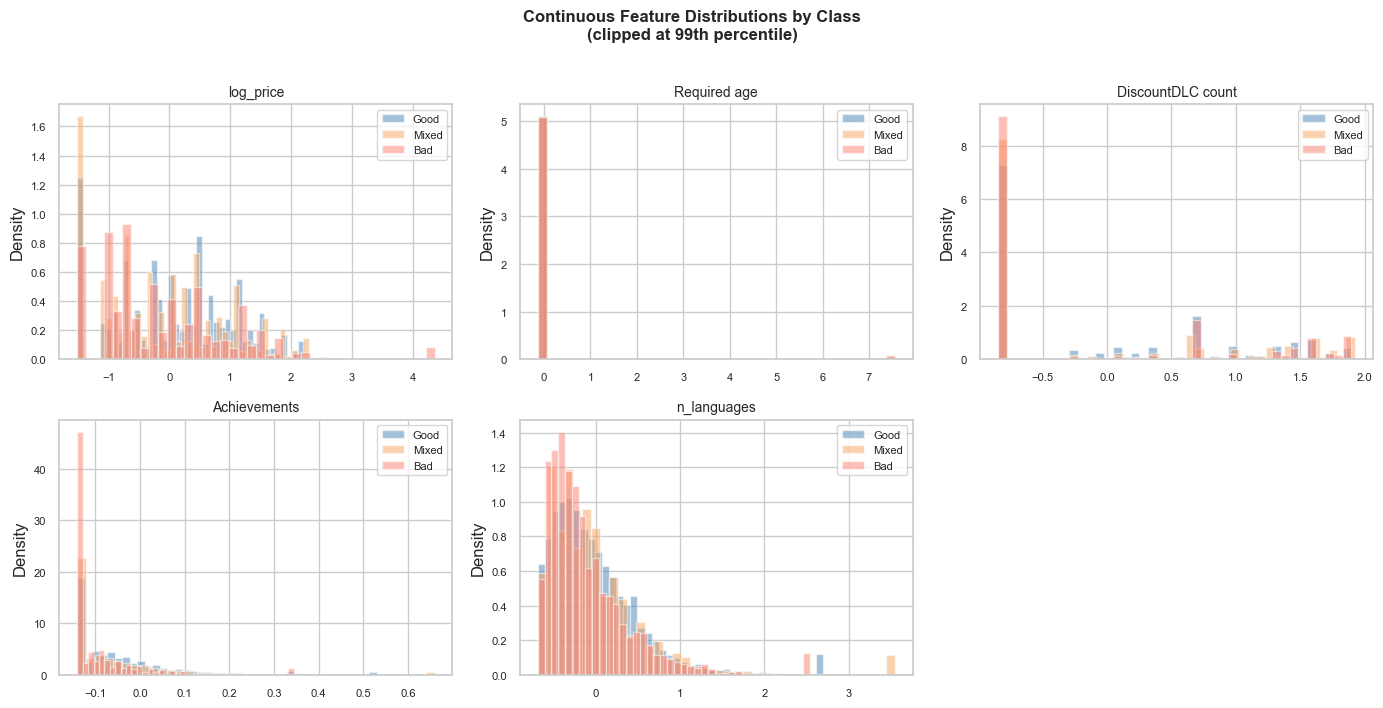

In [9]:
n_cols = 3
n_rows = (len(continuous_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    for cls in CLASS_ORDER:
        data = X.loc[y == cls, col].dropna()
        cap  = data.quantile(0.99)
        ax.hist(data.clip(upper=cap), bins=40, alpha=0.5,
                color=CLASS_COLORS[cls], label=cls, density=True)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

for j in range(len(continuous_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Continuous Feature Distributions by Class\n(clipped at 99th percentile)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Step 9 – Correlation Heatmap

We compute pairwise Pearson correlations between the continuous features and the label.  
High correlations between features may indicate redundancy (multicollinearity).

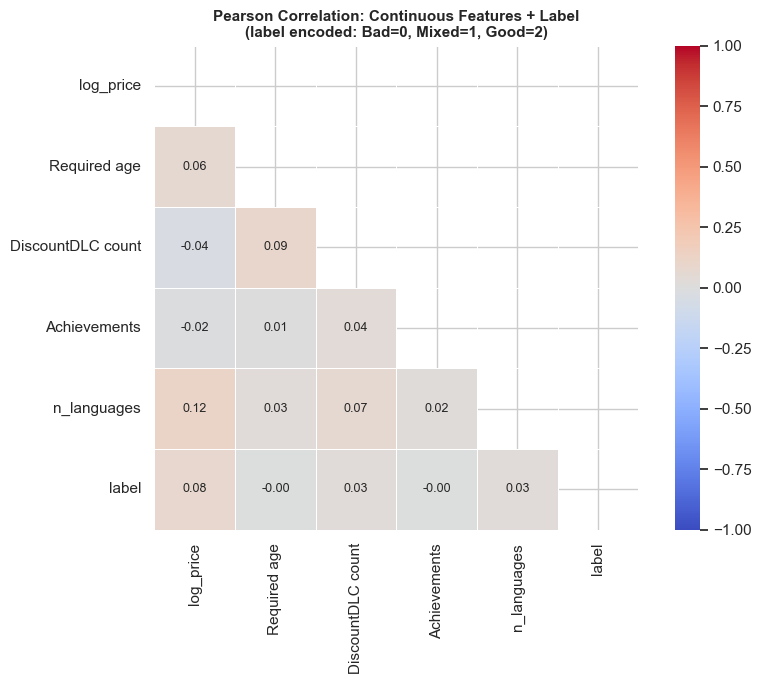

Feature correlation with label:
log_price            0.083
n_languages          0.027
DiscountDLC count    0.025
Required age        -0.005
Achievements        -0.003


In [10]:
label_enc = y.map({'Bad': 0, 'Mixed': 1, 'Good': 2})

corr_df = X[continuous_cols].copy()
corr_df['label'] = label_enc.values
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5,
    ax=ax, annot_kws={'size': 9}
)
ax.set_title('Pearson Correlation: Continuous Features + Label\n(label encoded: Bad=0, Mixed=1, Good=2)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

label_corr = corr_matrix['label'].drop('label').sort_values(key=abs, ascending=False)
print('Feature correlation with label:')
print(label_corr.round(3).to_string())

---
## Step 10 – Outlier Identification (IQR Method)

An outlier is any value below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.  
These are not removed — they are valid games (e.g. a game with very high playtime).  
This informs how linear vs tree-based models will handle extreme values.

IQR outlier analysis:
          feature    Q1    Q3  IQR  lower_bound  upper_bound  n_outliers  pct_outliers
     Achievements -0.14 -0.01 0.13        -0.34         0.19        2321          5.12
      n_languages -0.41  0.20 0.61        -1.33         1.12        1745          3.85
     Required age -0.14 -0.14 0.00        -0.14        -0.14         844          1.86
        log_price -0.75  0.68 1.43        -2.90         2.82         191          0.42
DiscountDLC count -0.85  0.83 1.68        -3.36         3.35           0          0.00


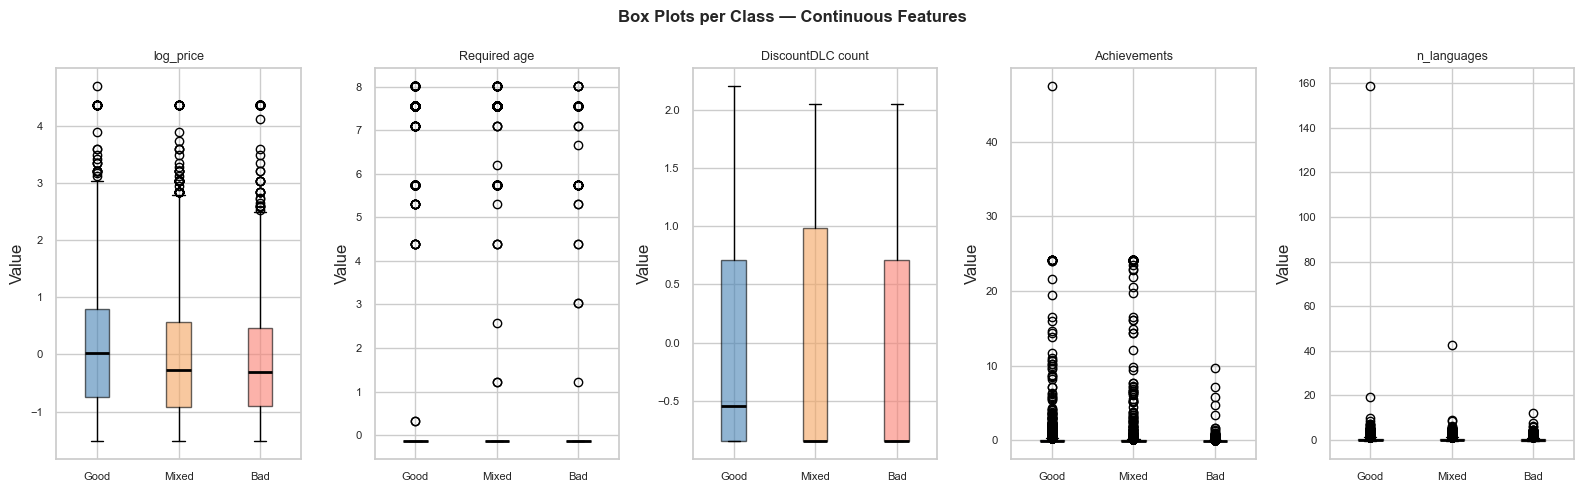

In [11]:
outlier_report = []
for col in continuous_cols:
    q1  = X[col].quantile(0.25)
    q3  = X[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((X[col] < lower) | (X[col] > upper)).sum()
    outlier_report.append({
        'feature'     : col,
        'Q1'          : round(q1, 2),
        'Q3'          : round(q3, 2),
        'IQR'         : round(iqr, 2),
        'lower_bound' : round(lower, 2),
        'upper_bound' : round(upper, 2),
        'n_outliers'  : n_out,
        'pct_outliers': round(n_out / len(X) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_report).sort_values('pct_outliers', ascending=False)
print('IQR outlier analysis:')
print(outlier_df.to_string(index=False))

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(16, 5))
for i, col in enumerate(continuous_cols):
    data = [X.loc[y == cls, col] for cls in CLASS_ORDER]
    bp = axes[i].boxplot(data, labels=CLASS_ORDER, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, cls in zip(bp['boxes'], CLASS_ORDER):
        patch.set_facecolor(CLASS_COLORS[cls])
        patch.set_alpha(0.6)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Value')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Box Plots per Class — Continuous Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 11 – Language Support

More languages = wider audience reach. We check if games with more language support tend to score better.

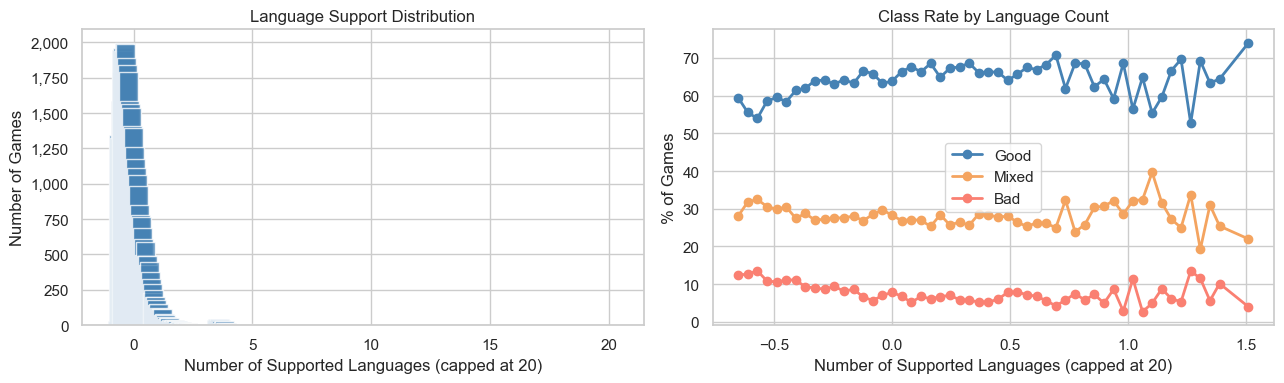

In [12]:
lang_cap = X['n_languages'].clip(upper=20)

lang_data = {}
for cls in CLASS_ORDER:
    lang_data[cls] = pd.Series({
        n: (y[lang_cap == n] == cls).mean() * 100
        for n in sorted(lang_cap.unique())
        if (lang_cap == n).sum() >= 50
    })

lang_counts = lang_cap.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(lang_counts.index, lang_counts.values, color=GOOD_COLOR, alpha=0.8)
axes[0].set_xlabel('Number of Supported Languages (capped at 20)')
axes[0].set_ylabel('Number of Games')
axes[0].set_title('Language Support Distribution')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for cls in CLASS_ORDER:
    axes[1].plot(lang_data[cls].index, lang_data[cls].values,
                 marker='o', color=CLASS_COLORS[cls], label=cls, linewidth=2)
axes[1].set_xlabel('Number of Supported Languages (capped at 20)')
axes[1].set_ylabel('% of Games')
axes[1].set_title('Class Rate by Language Count')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 12 – EDA Summary

In [13]:
print('=' * 60)
print('EDA SUMMARY')
print('=' * 60)
for cls in CLASS_ORDER:
    c = (y == cls).sum()
    p = c / len(y) * 100
    print(f'  {cls:6s}: {c:>7,}  ({p:.1f}%)')

print(f"""
Train set size   : {len(X):,} games x {X.shape[1]} features
Missing values   : 0 (imputed in preprocessing)

Feature groups:
  {len([c for c in X.columns if c.startswith('genre_')])} genre dummies
  {len([c for c in X.columns if c.startswith('cat_')])} category dummies
  {len([c for c in X.columns if c.startswith('tag_')])} tag dummies
  {len([c for c in X.columns if c.startswith('era_')])} era buckets
  {len(continuous_cols)} continuous features

Imbalance note: Bad class is ~8% — use class_weight='balanced' in all models.
""")
print('=' * 60)

EDA SUMMARY
  Good  :  28,671  (63.3%)
  Mixed :  12,834  (28.3%)
  Bad   :   3,819  (8.4%)

Train set size   : 45,324 games x 147 features
Missing values   : 0 (imputed in preprocessing)

Feature groups:
  28 genre dummies
  58 category dummies
  50 tag dummies
  3 era buckets
  5 continuous features

Imbalance note: Bad class is ~8% — use class_weight='balanced' in all models.



---

### Section 3 Checklist

| Analysis | Status |
|----------|--------|
| Class balance bar chart | done |
| Price distribution (free vs paid) | done |
| Top genres frequency + good rate | done |
| Top tags by good rate (best / worst) | done |
| Platform availability | done |
| Release era distribution | done |
| Continuous feature histograms (Good vs Bad) | done |
| Pearson correlation heatmap | done |
| IQR outlier analysis + box plots | done |
| Language support vs good rate | done |

**Output:** No new files are written. All modelling notebooks load from the same Parquet files.